# Introducción a Numpy, Pandas y Matplotlib

## Dataset: Ventas de videojuegos

- Numpy: operacion númericas y álgebra vectorial

- Pandas: Manipulación y anális de datos tabulares

- Matplotlib Visusalización de datos

Uso de `!` y `%` nos sirve para ejcutar comandos desde la terminal

`!` Cuando ejecutamos los comandos no valida entornos
`%` Valida entornos en los comandos

In [10]:
%pip install pandas
%pip install numpy
%pip install matplotlib

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Numpy

In [12]:
ventas_na = np.array([41.49, 29.08, 15.85, 15.75, 11.27]) # Vetnas por milloes
ventas_eu = np.array([29.02,  3.58, 12.88, 11.01,  8.89])

print("Arreglo: ", ventas_na)
print("Tipo de dato:", ventas_na.dtype)
print("Dimensiones:", ventas_na.ndim)
print("Forma", ventas_na.shape)

Arreglo:  [41.49 29.08 15.85 15.75 11.27]
Tipo de dato: float64
Dimensiones: 1
Forma (5,)


In [13]:
# Operaciones

ventas_total = ventas_na + ventas_eu
print("Ventas totales", ventas_total)

ventas_miles = ventas_na * 1000000
print("Ventas valor real", ventas_miles)

Ventas totales [70.51 32.66 28.73 26.76 20.16]
Ventas valor real [41490000. 29080000. 15850000. 15750000. 11270000.]


In [14]:
# Estadistica

print("Media", np.mean(ventas_na))
print("Mediana", np.median(ventas_na))
print("Deviación estandar:", np.std(ventas_na))
print("Minimo", np.min(ventas_na))
print("Maximo", np.max(ventas_na))

Media 22.687999999999995
Mediana 15.85
Deviación estandar: 11.132274520510173
Minimo 11.27
Maximo 41.49


In [15]:
# Subconjuntos del arreglo

print("Primer elemento:", ventas_na[0])
print("Úlitmos 3:", ventas_na[-3:])

# Filtros - Mascaras

grandes = ventas_na[ventas_na > 20]
print("Venstas mayores a 20 M:", grandes)

Primer elemento: 41.49
Úlitmos 3: [15.85 15.75 11.27]
Venstas mayores a 20 M: [41.49 29.08]


In [16]:
# Arreglos 2D

matriz_ventas = np.column_stack([ventas_na, ventas_eu])
print("Forma:", matriz_ventas.shape)
print(matriz_ventas)

# Operaciones sobre ejes
print("Media por region", np.mean(matriz_ventas, axis=0))
print("Total por juegos", np.sum(matriz_ventas, axis=1))

Forma: (5, 2)
[[41.49 29.02]
 [29.08  3.58]
 [15.85 12.88]
 [15.75 11.01]
 [11.27  8.89]]
Media por region [22.688 13.076]
Total por juegos [70.51 32.66 28.73 26.76 20.16]


In [17]:
# Generación de nuemeros

rng = np.random.default_rng(seed=42)
muestra_aleatoria = rng.normal(loc=10, scale=5, size=1000)
print("Media:", muestra_aleatoria.mean())
print("Desviacion estandar", muestra_aleatoria.std())
print("forma", muestra_aleatoria.shape)

Media: 9.855542245020267
Desviacion estandar 4.94361177698254
forma (1000,)


# Pandas

In [18]:
df = pd.read_csv("vgsales.csv")
df.shape

(16598, 11)

In [19]:
# Limpieza

print("Valores por columna")
print(df.isnull().sum())

Valores por columna
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [20]:
df_limpio = df.dropna(subset=["Year", "Publisher"])
print("Filas originales:", len(df))
print("Limpio:", len(df_limpio))

Filas originales: 16598
Limpio: 16291


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [22]:
df_limpio = df_limpio.copy()
df_limpio["Year"] = df_limpio["Year"].astype(int)
print(df_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB
None


In [23]:
# Duplicados

n_duplicados = df_limpio.duplicated().sum()
print("Duplicados", n_duplicados)
df_limpio = df_limpio.drop_duplicates()

Duplicados 0


In [24]:
# Renombrado de columas

df_limpio = df_limpio.rename(columns={
    "NA_Sales"     : "ventas_na",
    "EU_Sales"     : "ventas_eu",
    "JP_Sales"     : "ventas_jp",
    "Other_Sales"  : "ventas_otros",
    "Global_Sales" : "ventas_global",
})

In [25]:
p99 = df_limpio["ventas_global"].quantile(0.99)
outliners = df_limpio[df_limpio["ventas_global"] > p99]

print("Percentil 99:", p99)
print("Oulilers:", len(outliners))

Percentil 99: 5.472000000000007
Oulilers: 163


In [26]:
# Columnas derivas

df_limpio["ventas_occidente"] = df_limpio["ventas_na"] + df_limpio['ventas_eu']
df_limpio["prop_na"] = df_limpio["ventas_na"] / df_limpio["ventas_global"]
df_limpio[["Name", "ventas_na", "ventas_eu", "ventas_occidente", "prop_na"]].sample(5)

,Name,ventas_na,ventas_eu,ventas_occidente,prop_na
2438,Blazing Angels: Squadrons of WWII,0.74,0.04,0.78,0.870588
5236,Dance Dance Revolution 3rdMix,0.00,0.00,0.00,0.000000
6609,Combination Pro Soccer: J-League no Kantoku ni...,0.00,0.00,0.00,0.000000
9649,Armed and Dangerous,0.09,0.03,0.12,0.692308
475,Devil May Cry,1.36,0.86,2.22,0.454849


In [27]:
nombres   = df_limpio["Name"]          # Series
regiones  = df_limpio[["Name", "ventas_na", "ventas_eu"]]  # DataFrame
print(type(nombres), type(regiones))

<class 'pandas.core.series.Series'> <class 'pandas.core.frame.DataFrame'>


In [28]:
nintendo = df_limpio[df_limpio["Publisher"] == "Nintendo"]
print(f"Juegos de Nintendo: {len(nintendo)}")
nintendo[["Name", "Genre", "ventas_global"]].head(8)

Juegos de Nintendo: 696


,Name,Genre,ventas_global
0,Wii Sports,Sports,82.74
1,Super Mario Bros.,Platform,40.24
2,Mario Kart Wii,Racing,35.82
3,Wii Sports Resort,Sports,33.00
4,Pokemon Red/Pokemon Blue,Role-Playing,31.37
5,Tetris,Puzzle,30.26
6,New Super Mario Bros.,Platform,30.01
7,Wii Play,Misc,29.02


In [29]:
nintendoShooter = df_limpio[
    (df_limpio["Publisher"] == "Nintendo") &
    (df_limpio["Genre"] == "Shooter")
]
print(nintendoShooter[["Name", "Platform", "ventas_global"]])

                                     Name Platform  ventas_global
9                               Duck Hunt      NES          28.31
84                          GoldenEye 007      N64           8.09
206              Link's Crossbow Training      Wii           5.00
235                              Splatoon     WiiU           4.57
296                           Star Fox 64      N64           4.03
472                              Star Fox     SNES           2.99
519                         Metroid Prime       GC           2.82
955           Metroid Prime 3: Corruption      Wii           1.82
1108                        Super Scope 6     SNES           1.65
1476              Metroid Prime 2: Echoes       GC           1.33
1560                        Hogan's Alley      NES           1.27
1678                         SolarStriker       GB           1.20
1750                     Jet Force Gemini      N64           1.16
1914                    Star Fox: Assault       GC           1.08
2197      

In [30]:
# Funciones de agregación + groupby

ventas_por_genero = (
    df_limpio
    .groupby("Genre")["ventas_global"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "total_M", "mean": "proemdio_M", "count": "n_juegos"})
    .sort_values("total_M", ascending=False)
)

ventas_por_genero

,total_M,proemdio_M,n_juegos
Genre,,,
Action,1722.84,0.529942,3251
Sports,1309.24,0.568247,2304
Shooter,1026.20,0.800468,1282
Role-Playing,923.83,0.628456,1470
Platform,829.13,0.947577,875
Misc,789.87,0.468488,1686
Racing,726.76,0.593273,1225
Fighting,444.05,0.531160,836
Simulation,389.98,0.459882,848


In [31]:
# Tabla pivote

top_generos = ["Action", "Sports", "Shooter", "Role-Playing", "Racing"]
top_plataformas = ["PS2", "X360", "Wii", "PS3", "DS"]

pivot = pd.pivot_table(
    df_limpio[df_limpio["Genre"].isin(top_generos) &
              df_limpio["Platform"].isin(top_plataformas)],
    values= "ventas_global",
    index = "Genre",
    columns="Platform",
    aggfunc="sum",
    fill_value=0
)
pivot

Platform,DS,PS2,PS3,Wii,X360
Genre,,,,,
Action,114.16,272.43,304.02,110.48,239.67
Racing,38.58,154.21,73.10,61.24,65.13
Role-Playing,126.56,91.55,75.24,14.06,71.97
Shooter,8.20,108.28,195.80,26.34,277.23
Sports,31.71,262.64,134.91,289.95,137.43


In [32]:
# Distrubución de valores

print(df_limpio["Genre"].value_counts())

Genre
Action          3251
Sports          2304
Misc            1686
Role-Playing    1470
Shooter         1282
Adventure       1274
Racing          1225
Platform         875
Simulation       848
Fighting         836
Strategy         670
Puzzle           570
Name: count, dtype: int64


# Matplotlib

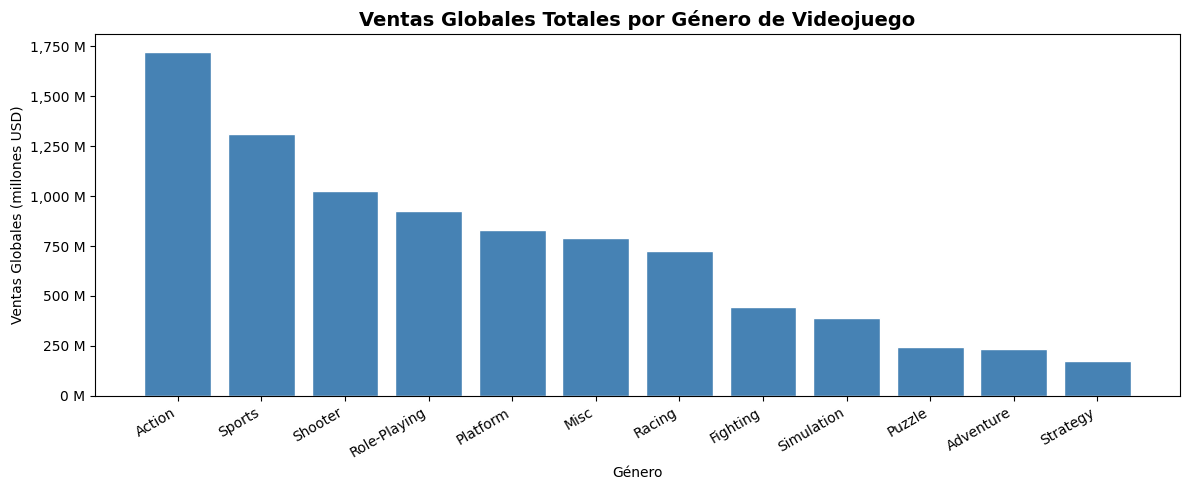

In [38]:
# Grafico de barras

ventas_genero = (
    df_limpio.groupby("Genre")["ventas_global"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ventas_genero.index, ventas_genero.values, color="steelblue", edgecolor="white")
ax.set_title("Ventas Globales Totales por Género de Videojuego", fontsize=14, fontweight="bold")
ax.set_xlabel("Género")
ax.set_ylabel("Ventas Globales (millones USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} M"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

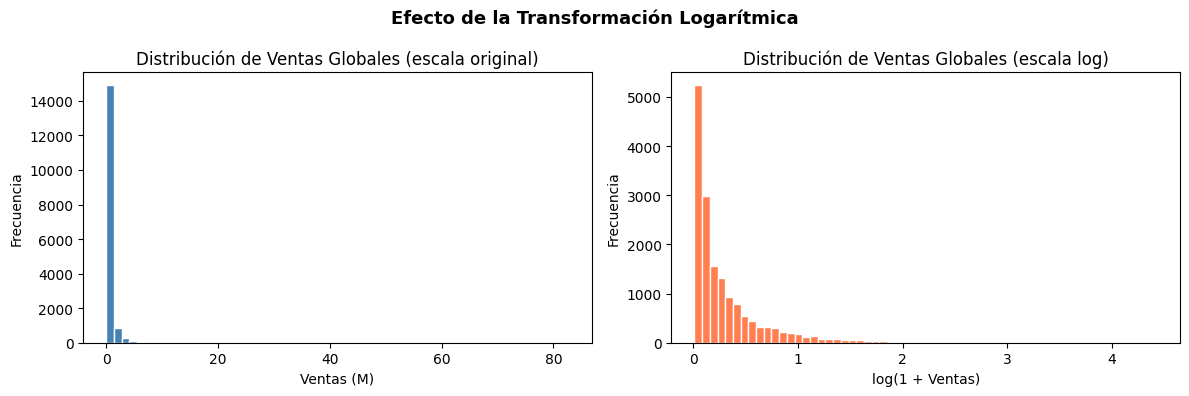

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Escala original: distribución muy sesgada a la derecha (long tail).
axes[0].hist(df_limpio["ventas_global"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de Ventas Globales (escala original)")
axes[0].set_xlabel("Ventas (M)")
axes[0].set_ylabel("Frecuencia")

# Transformación logarítmica: normaliza la distribución sesgada.
# Muchos algoritmos de ML asumen distribuciones aproximadamente normales.
log_ventas = np.log1p(df_limpio["ventas_global"])  # log(1+x) evita log(0)
axes[1].hist(log_ventas, bins=60, color="coral", edgecolor="white")
axes[1].set_title("Distribución de Ventas Globales (escala log)")
axes[1].set_xlabel("log(1 + Ventas)")
axes[1].set_ylabel("Frecuencia")

plt.suptitle("Efecto de la Transformación Logarítmica", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

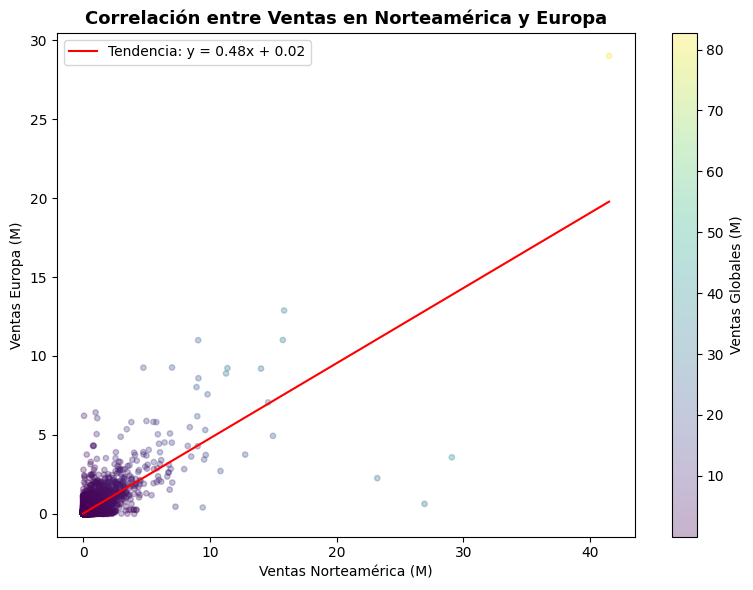

Coeficiente de correlación de Pearson (NA vs. EU): 0.7689


In [40]:
# Diagra de dispersión

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    df_limpio["ventas_na"],
    df_limpio["ventas_eu"],
    alpha=0.3,
    s=15,
    c=df_limpio["ventas_global"],  # color codificado por ventas globales
    cmap="viridis",
)
plt.colorbar(scatter, ax=ax, label="Ventas Globales (M)")

# Línea de tendencia lineal calculada con NumPy (regresión de mínimos cuadrados).
# Anticipa el concepto de regresión lineal que se abordará en ML.
mask = df_limpio["ventas_na"].notna() & df_limpio["ventas_eu"].notna()
coef = np.polyfit(df_limpio.loc[mask, "ventas_na"], df_limpio.loc[mask, "ventas_eu"], deg=1)
x_line = np.linspace(0, df_limpio["ventas_na"].max(), 200)
ax.plot(x_line, np.polyval(coef, x_line), color="red", linewidth=1.5,
        label=f"Tendencia: y = {coef[0]:.2f}x + {coef[1]:.2f}")

ax.set_title("Correlación entre Ventas en Norteamérica y Europa", fontsize=13, fontweight="bold")
ax.set_xlabel("Ventas Norteamérica (M)")
ax.set_ylabel("Ventas Europa (M)")
ax.legend()
plt.tight_layout()
plt.show()

corr = df_limpio["ventas_na"].corr(df_limpio["ventas_eu"])
print(f"Coeficiente de correlación de Pearson (NA vs. EU): {corr:.4f}")

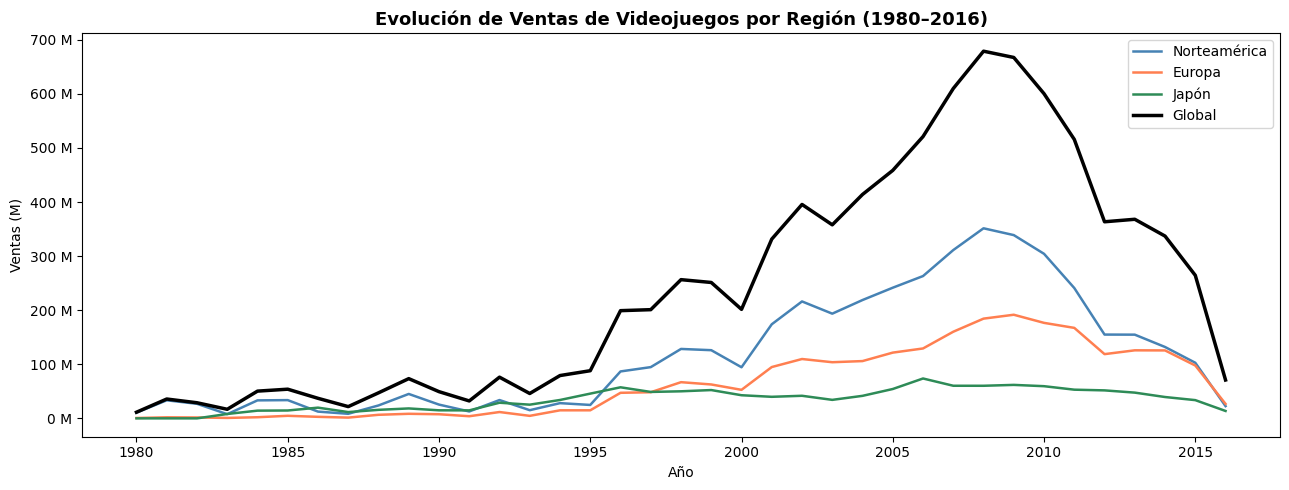

In [41]:
ventas_anuales = (
    df_limpio
    .groupby("Year")[["ventas_na", "ventas_eu", "ventas_jp", "ventas_global"]]
    .sum()
    .loc[1980:2016]  # se excluyen años con muy pocos registros en los extremos
)

fig, ax = plt.subplots(figsize=(13, 5))
for col, label, color in [
    ("ventas_na",     "Norteamérica", "steelblue"),
    ("ventas_eu",     "Europa",       "coral"),
    ("ventas_jp",     "Japón",        "seagreen"),
    ("ventas_global", "Global",       "black"),
]:
    ax.plot(ventas_anuales.index, ventas_anuales[col],
            label=label, color=color, linewidth=1.8 if col != "ventas_global" else 2.5)

ax.set_title("Evolución de Ventas de Videojuegos por Región (1980–2016)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Ventas (M)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} M"))
plt.tight_layout()
plt.show()


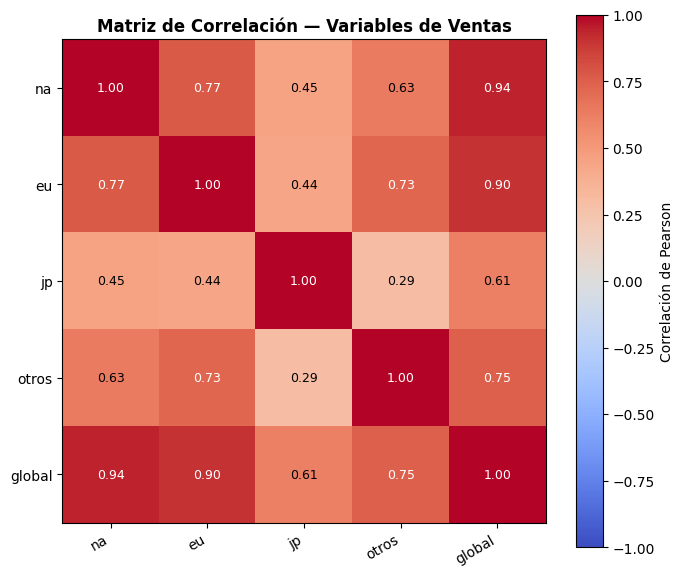

In [42]:
# Mapa de calor de correlaciones

columnas_num = ["ventas_na", "ventas_eu", "ventas_jp", "ventas_otros", "ventas_global"]
corr_matrix  = df_limpio[columnas_num].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Correlación de Pearson")

# Anotación de cada celda con el valor numérico de la correlación.
for i in range(len(columnas_num)):
    for j in range(len(columnas_num)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.7 else "black")

etiquetas = [c.replace("ventas_", "") for c in columnas_num]
ax.set_xticks(range(len(columnas_num)))
ax.set_yticks(range(len(columnas_num)))
ax.set_xticklabels(etiquetas, rotation=30, ha="right")
ax.set_yticklabels(etiquetas)
ax.set_title("Matriz de Correlación — Variables de Ventas", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()